# Hoogsteen detection exploration
Notebook for experimenting with Watson-Crick → Hoogsteen baseflip detection and analysis.

Create helper functions in `mdna` as needed and import them here to prototype algorithms.

In [1]:
# Basic imports to get started
import sys
from pathlib import Path
# add repo root to path if running from a different cwd
repo_root = Path('..').resolve()
sys.path.insert(0, str(repo_root))
import mdna
print('mdna imported, version:', getattr(mdna, '__version__', 'unknown'))

mdna imported, version: 0.2.0


## Prototype: build mock flip trajectory
We'll iteratively apply a base flip from 0→180° in `n_steps`, collect single-frame trajectories from `get_traj()`, join them into a multi-frame trajectory, then load that into `mdna` for analysis.
Adjust `mdna.make()` and `base_idx` for your sequence and API surface.

In [20]:
# Parameters
n_steps = 100
base_idx = 4  # adjust to the base index you want to flip (0-based)
# Create an initial dna object using mdna.make(); adjust this call to your API if needed
import copy
from pathlib import Path
try:
    dna0 = mdna.make(n_bp=6)  # try length-based constructor first
except Exception:
    try:
        dna0 = mdna.make('ATATATA')
    except Exception as e:
        raise RuntimeError('Could not construct dna with mdna.make(); adjust the call for your local API') from e
    
dna0.describe()

Random sequence: AAGACC 


Start rescaling spline based on requested number of base pairs.
	This requires recomputation of the control points to match the desired number of base pairs.
	Spline scaled to match the target number of base pairs: 6

DNA structure with 6 base pairs
Sequence: AAGACC
Trajectory not loaded
Frames:  (6, 1, 4, 3)


In [21]:
import mdtraj as md
trajs = []
for step in range(n_steps + 1):
    angle = 360.0 * (step / n_steps)
    d = copy.deepcopy(dna0)
    # call flip; try a couple of possible signatures
    if hasattr(d, 'flip'):
        try:
            d.flip([base_idx], angle)
        except TypeError:
            try:
                d.flip([base_idx], deg=angle)
            except Exception as e:
                raise
    else:
        raise AttributeError('dna object has no .flip() method; check mdna API')
    traj = d.get_traj()  # expected to be an mdtraj.Trajectory (single frame)
    trajs.append(traj)
    
flipped_traj = md.join(trajs)

Flipped residues [4] by 0.0 radians
Flipped residues [4] by 0.06283185307179587 radians
Flipped residues [4] by 0.12566370614359174 radians
Flipped residues [4] by 0.18849555921538758 radians
Flipped residues [4] by 0.25132741228718347 radians
Flipped residues [4] by 0.3141592653589793 radians
Flipped residues [4] by 0.37699111843077515 radians
Flipped residues [4] by 0.4398229715025711 radians
Flipped residues [4] by 0.5026548245743669 radians
Flipped residues [4] by 0.5654866776461628 radians
Flipped residues [4] by 0.6283185307179586 radians
Flipped residues [4] by 0.6911503837897546 radians
Flipped residues [4] by 0.7539822368615503 radians
Flipped residues [4] by 0.8168140899333463 radians
Flipped residues [4] by 0.8796459430051422 radians
Flipped residues [4] by 0.9424777960769379 radians
Flipped residues [4] by 1.0053096491487339 radians
Flipped residues [4] by 1.0681415022205298 radians
Flipped residues [4] by 1.1309733552923256 radians
Flipped residues [4] by 1.193805208364121

In [22]:
import nglview as nv
view = nv.show_mdtraj(flipped_traj)
view.clear()
view.add_representation('licorice', selection='all')
view


NGLWidget(max_frame=100)

## Load into mdna and inspect rigid-base parameters
Try loading the joined trajectory into `mdna` and compute rigid-base parameters to inspect how the flipped base frames behave during the flip. Replace analysis call names with the correct `mdna` API if needed.

In [23]:
dna_flipped = mdna.load(flipped_traj)

Text(0.02, 0.5, 'Base index')

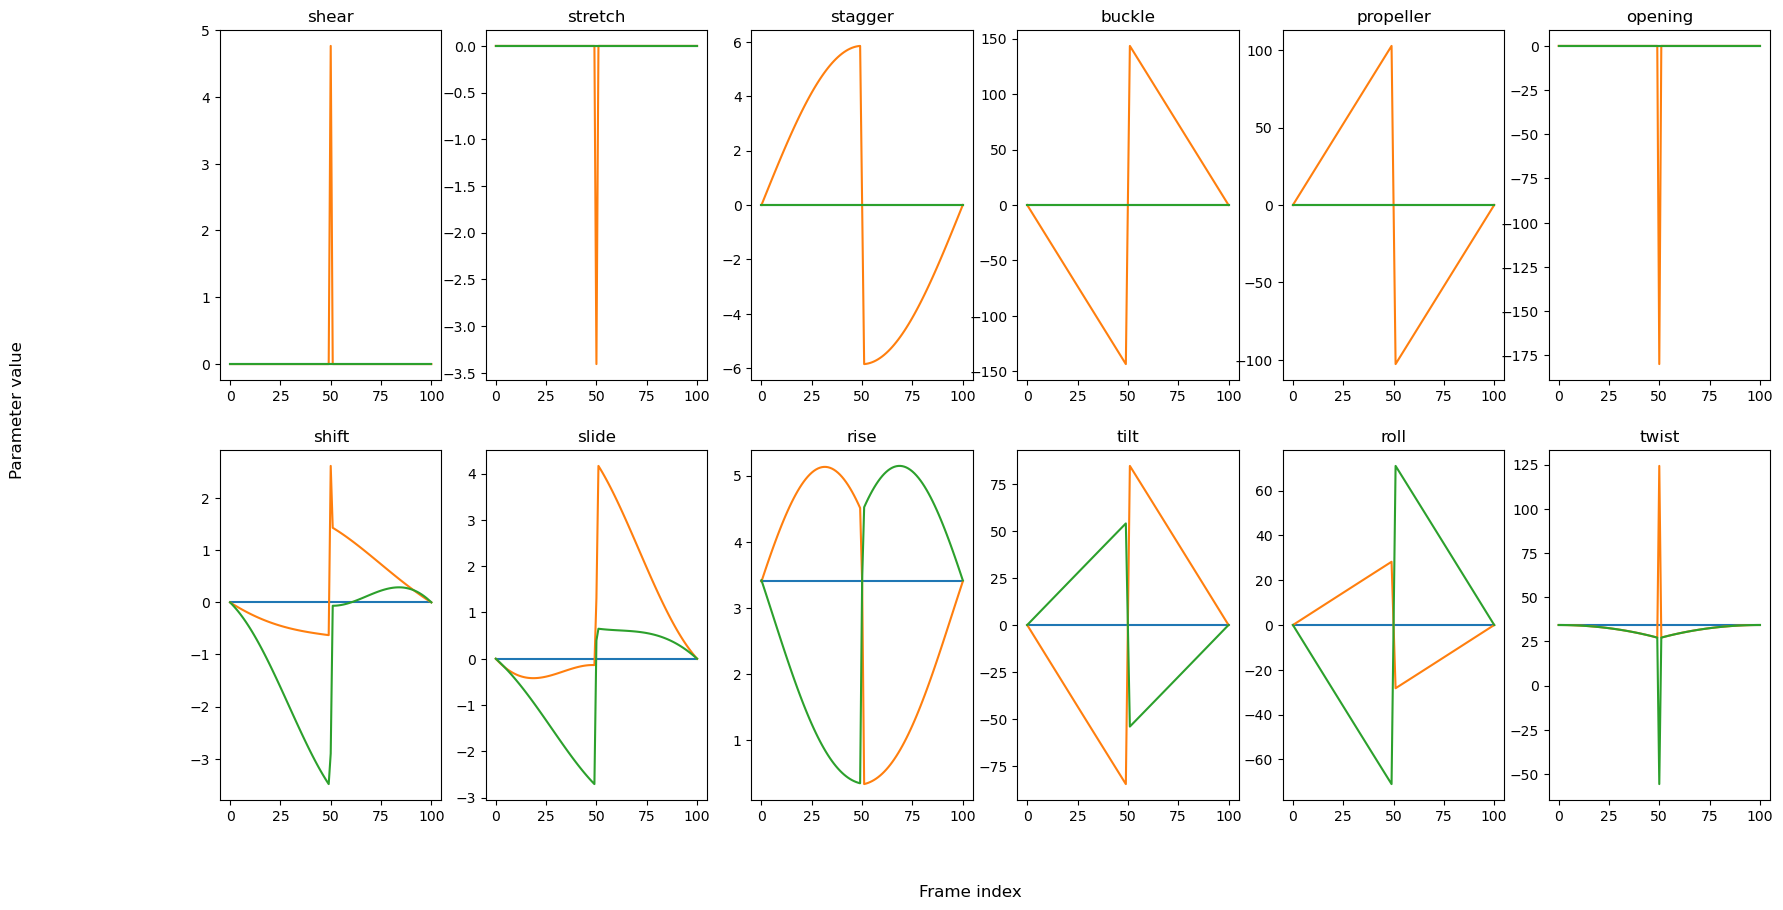

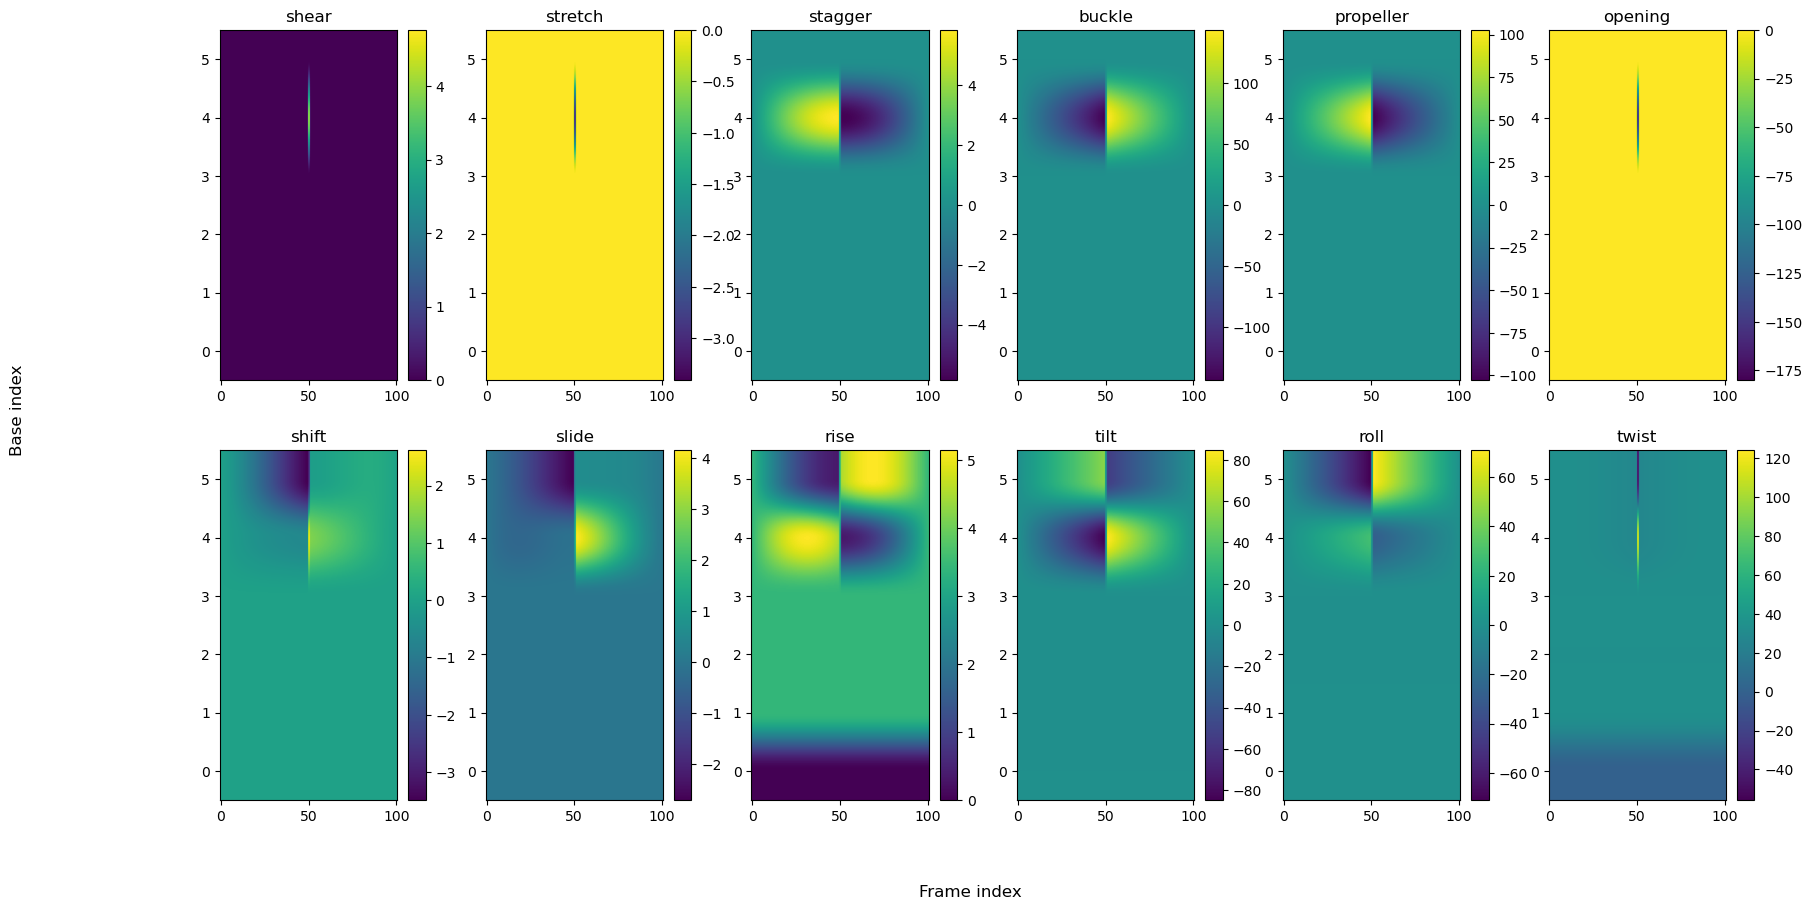

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 6, figsize=(20, 10))
ax = ax.flatten()

params, names = dna_flipped.get_parameters()
params.shape  # frames, base_index, parameter

# for each parameter, plot the value for the flipped base (base_idx) across all frames
for i, name in enumerate(names):
    im = ax[i].plot(params[:, base_idx, i])
    ax[i].set_title(name)

# also plot as a heatmap with y axis base index and x axis frame index and color the parameter value
for i, name in enumerate(names):
    im = ax[i].imshow(params[:, :, i].T, aspect='auto', origin='lower')
    ax[i].set_title(name)

# one shared color label for the whole figure
cbar = fig.colorbar(im, ax=ax.tolist(), shrink=0.85)
cbar.set_label('Parameter value')

fig.supxlabel('Frame index')
fig.supylabel('Base index')


# also plot as a heatmap with y axis base index and x axis frame index and color the parameter value
fig, ax = plt.subplots(2,6, figsize=(20,10))
ax = ax.flatten()
for i, name in enumerate(names):
    im = ax[i].imshow(params[:, :, i].T, aspect='auto', origin='lower')
    ax[i].set_title(name)
    fig.colorbar(im, ax=ax[i])  
    
fig.supxlabel('Frame index')
fig.supylabel('Base index')


In [25]:
# Save trajectory for later use; also save the first frame as a pdb for easy visualization in external tools
flipped_traj.save('flipped_traj.xtc')
flipped_traj[0].save('flipped_traj_frame0.pdb')